# Prompt Chaining
START -> GEN OUTLINE -> GENERATE BLOG -> END

In [1]:
from langgraph.graph import StateGraph, START, END
from langchain_openai import ChatOpenAI
from typing import TypedDict
from dotenv import load_dotenv
import os

In [2]:
load_dotenv()

True

In [3]:
model = ChatOpenAI(
    model = "openai/gpt-4o-mini",
    api_key=os.getenv("OPENROUTER_API_KEY"),
    base_url="https://openrouter.ai/api/v1",
    max_tokens = 500
)

In [4]:
class BlogState(TypedDict):
    title: str
    outline: str
    blog: str
    score: str

In [5]:
graph = StateGraph(BlogState)

In [6]:
def create_outline(state: BlogState) -> BlogState:

    # fetch title
    title = state['title']

    # from prompt
    prompt = f"create an mini and short outline for given topic to create a blog: {title}"

    # answer 
    outline = model.invoke(prompt).content

    # update state
    state['outline'] = outline

    return state

In [7]:
def create_blog(state: BlogState) -> BlogState:

    # fetch title
    title = state['title']
    outline = state['outline']

    # from prompt
    prompt = f'Generate a short and mini blog with title {title} and given outline as: \n {outline}'

    # blog generation 
    blog = model.invoke(prompt).content

    # update state
    state['blog'] = blog

    return state

In [8]:
def generate_score(state: BlogState) -> BlogState:

    # fetch title
    blog = state['blog']
    outline = state['outline']

    prompt = f'Score the blog out of 10 against the outline we created: \n {outline}. Blog: \n {blog}'

    score = model.invoke(prompt).content

    state['score'] = score

    return state

In [9]:
graph.add_node('create_outline', create_outline)
graph.add_node('create_blog', create_blog)
graph.add_node('generate_score', generate_score)

In [10]:
graph.add_edge(START, 'create_outline')
graph.add_edge('create_outline', 'create_blog')
graph.add_edge('create_blog', 'generate_score')
graph.add_edge('generate_score', END)

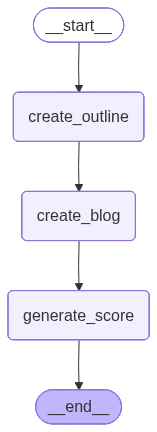

In [11]:
graph.compile()

In [12]:
workflow = graph.compile()

In [13]:
initial_state = {'title': 'rise of AI in India'}

In [14]:
final_state = workflow.invoke(initial_state)

In [15]:
print(final_state)

{'title': 'rise of AI in India', 'outline': "### Blog Outline: The Rise of AI in India\n\n#### I. Introduction\n   - Brief overview of AI and its global significance\n   - Importance of examining AI's growth specifically in India\n\n#### II. Historical Context\n   - Early developments in AI in India\n   - Key milestones in AI research and innovation\n\n#### III. Driving Factors behind AI Growth in India\n   - Government initiatives and policies\n   - Increased investment from startups and tech companies\n   - Growing access to data and computational power\n\n#### IV. Current AI Landscape\n   - Major players in the Indian AI industry (startups, corporates, academia)\n   - Sector-wise applications: healthcare, agriculture, finance, education, etc.\n\n#### V. Challenges and Considerations\n   - Infrastructure and skill gaps\n   - Ethical considerations and data privacy concerns\n\n#### VI. Future Prospects\n   - Potential growth areas for AI in India\n   - Predictions for AI's impact on t

In [16]:
print(final_state['outline'])

### Blog Outline: The Rise of AI in India

#### I. Introduction
   - Brief overview of AI and its global significance
   - Importance of examining AI's growth specifically in India

#### II. Historical Context
   - Early developments in AI in India
   - Key milestones in AI research and innovation

#### III. Driving Factors behind AI Growth in India
   - Government initiatives and policies
   - Increased investment from startups and tech companies
   - Growing access to data and computational power

#### IV. Current AI Landscape
   - Major players in the Indian AI industry (startups, corporates, academia)
   - Sector-wise applications: healthcare, agriculture, finance, education, etc.

#### V. Challenges and Considerations
   - Infrastructure and skill gaps
   - Ethical considerations and data privacy concerns

#### VI. Future Prospects
   - Potential growth areas for AI in India
   - Predictions for AI's impact on the Indian economy and society

#### VII. Conclusion
   - Recap of AI's

In [17]:
print(final_state['blog'])

# The Rise of AI in India

### I. Introduction
Artificial Intelligence (AI) has rapidly transformed various sectors worldwide, driving innovation and efficiency in unprecedented ways. As a burgeoning force in technology, AI’s potential holds the promise of reshaping economies and societies across the globe. In this context, India stands out as a significant player in the AI landscape, making it crucial to examine the specific growth trajectories of AI in this diverse nation.

### II. Historical Context
While India’s engagement with AI is relatively recent, the seeds were planted in the early 1980s with foundational research in machine learning and natural language processing. The establishment of academic institutions and government-sponsored research programs marked key milestones in AI innovation, setting the stage for a thriving ecosystem.

### III. Driving Factors behind AI Growth in India
Several catalysts are propelling AI’s growth in India. Government initiatives, like the Natio

In [18]:
print(final_state['score'][:])

**Score: 8.5/10**

**Evaluation Against the Outline:**

1. **Introduction (9/10)**: The introduction effectively establishes the global significance of AI and emphasizes the need to focus on India's growth in this area. It engages the reader and sets a clear context—though a slightly more detailed outline of the blog’s structure could enhance clarity.

2. **Historical Context (8/10)**: This section provides a solid overview of India's early involvement in AI and mentions key milestones. However, it could benefit from more specific examples of significant achievements or pioneers in the field to enrich the narrative further.

3. **Driving Factors behind AI Growth in India (9/10)**: The blog clearly articulates the various drivers of AI growth, including government initiatives, investments, and access to data. It successfully highlights the interplay of these factors, though some more specific examples or statistics could strengthen the argument.

4. **Current AI Landscape (9/10)**: This